In [1]:
import pandas as pd

df = pd.read_parquet("../data/processed/cleaned.parquet")
print(df.shape)
df.head()

(223461, 2)


,text,label
0,"видимо в разных регионах называют по разному ,...",0
1,"понятно что это нарушение правил, писать капсл...",1
2,"какие классные, жизненные стихи....",0
3,а и правда-когда его запретили?...,0
4,в соленой воде вирусы живут .ученые изучали со...,0


In [2]:
toxic_only = df[df["label"] == 1]
non_toxic_only = df[df["label"] == 0]
print(toxic_only.shape)
print(non_toxic_only.shape)

toxic_only.head()

(40145, 2)
(183316, 2)


,text,label
1,"понятно что это нарушение правил, писать капсл...",1
5,правильно! это же тихановская 26 лет растила и...,1
13,"на хуй, безликая",1
16,дебилов хватает.надо было с головой,1
30,умник хуев. у каждого своё мнение,1


In [3]:
from transformers import AutoModelForSequenceClassification, AutoTokenizer
import torch

checkpoint_path = "../checkpoints/reward_model/final_checkpoint/"

tokenizer = AutoTokenizer.from_pretrained(checkpoint_path, local_files_only=True)
model = AutoModelForSequenceClassification.from_pretrained(checkpoint_path, local_files_only=True, device_map="auto")

model.eval()

def get_reward(prompts):
    inputs = tokenizer(prompts, return_tensors="pt", padding=True, truncation=True)
    inputs.to(model.device)
    with torch.no_grad():
        outputs = model(**inputs)
        return outputs.logits

In [4]:
toxic_text = toxic_only.iloc[1]['text']
nontoxic_text = non_toxic_only.iloc[0]['text']
print(toxic_text)
print(get_reward(toxic_text))
print('-' * 100)
print(nontoxic_text)
print(get_reward(nontoxic_text))

правильно! это же тихановская 26 лет растила и воспитывала омон и мвд в твердой уверенности,что любое беззаконие сойдёт им с рук. это она дала команду не церемониться ни с подростками ни со стариками. это тихановская грозила расстреливать всех,кто против. читая ваш комментарий, создаётся впечатление,что вы не умудренная опытом,а выжившая из ума,как и ваш кумир.
tensor([[3.1285]], device='mps:0')
----------------------------------------------------------------------------------------------------
видимо в разных регионах называют по разному , в ростовской области чаще называют шелковицей, реже тюте(и)ной или тутовником
tensor([[-7.4537]], device='mps:0')


In [5]:
def prepare_toxic_prompts(sample, prompt_tokens=10, return_text=False):
    """
    Split text into prompt and continuation parts.
    
    Args:
        sample: Dictionary with 'text' key or pandas Series with text
        prompt_tokens: Number of tokens to use for the prompt (default: 10)
        return_text: If True, return decoded text; if False, return token IDs
    
    Returns:
        tuple: (prompt, continuation) as either token IDs or text strings
    """

    full_text = sample['text']
    
    # Tokenize the full text
    tokens = tokenizer.encode(full_text, add_special_tokens=True)

    sample['token_count'] = len(tokens)
    
    # Handle edge case where text is shorter than prompt_tokens
    if len(tokens) <= prompt_tokens:
        sample['prompt'] = full_text
        sample['continuation'] = ""
        return sample
    
    # Split into prompt and continuation
    prompt_tokens_list = tokens[:prompt_tokens]
    continuation_tokens = tokens[prompt_tokens:]

    # Decode back to text
    prompt_text = tokenizer.decode(prompt_tokens_list, skip_special_tokens=True)
    continuation_text = tokenizer.decode(continuation_tokens, skip_special_tokens=True)

    sample['prompt'] = prompt_text
    sample['continuation'] = continuation_text

    return sample

In [6]:
import datasets

toxic_only_dataset = datasets.Dataset.from_pandas(toxic_only)
toxic_only_dataset = toxic_only_dataset.remove_columns(['label', '__index_level_0__'])

toxic_only_dataset

Dataset({
    features: ['text'],
    num_rows: 40145
})

In [7]:
prepared_dataset = toxic_only_dataset.map(prepare_toxic_prompts, fn_kwargs={'prompt_tokens': 5})
prepared_dataset = prepared_dataset.filter(lambda x: x['continuation'] != "")

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Map:   0%|          | 0/40145 [00:00<?, ? examples/s]

Filter:   0%|          | 0/40145 [00:00<?, ? examples/s]

In [8]:
prepared_dataset

Dataset({
    features: ['text', 'token_count', 'prompt', 'continuation'],
    num_rows: 38890
})

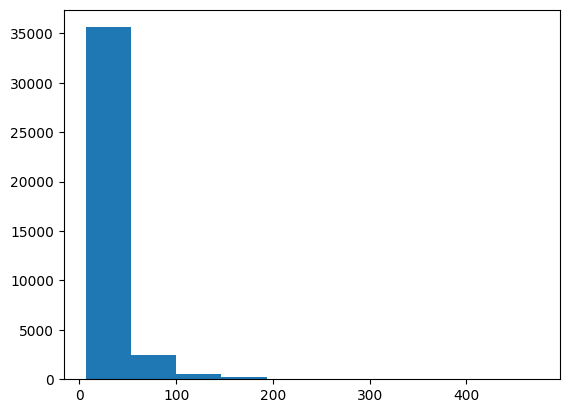

Mean: 25.16564669580869
Std: 24.27819761650213
Min: 7
Max: 473
Median: 17.0


In [9]:
import matplotlib.pyplot as plt
import numpy as np

tokens = np.array(prepared_dataset['token_count'])
plt.hist(tokens)
plt.show()

print(f"Mean: {tokens.mean()}")
print(f"Std: {tokens.std()}")
print(f"Min: {tokens.min()}")
print(f"Max: {tokens.max()}")
print(f"Median: {np.median(tokens)}")

In [11]:
prepared_dataset.save_to_disk('../data/prompts')

Saving the dataset (0/1 shards):   0%|          | 0/38890 [00:00<?, ? examples/s]